# Level 2 - Task 1: Regression Analysis
**Dataset:** House Price Prediction  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn, Statsmodels  
**Objective:** Build and evaluate regression models to predict house prices (MEDV)

In [2]:
# ============================
# 1. Import Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statsmodels
import statsmodels.api as sm

# Display settings
from IPython.display import display, HTML
display(HTML("<style>.output_result { max-height: 800px; }</style>"))
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================
# 2. Load Dataset
# ============================
import os

processed_path = '/workspaces/codveda_technologies-data_analysis_internship/data/processed/house_cleaned.csv'
raw_path = '/workspaces/codveda_technologies-data_analysis_internship/data/raw/4) house Prediction Data Set.csv'

if os.path.exists(processed_path):
    df = pd.read_csv(processed_path)
    print("Loaded from processed folder")
else:
    print("Using raw dataset...")
    df = pd.read_csv(raw_path, sep='\s+', header=None,
                     names=['crim','zn','indus','chas','nox','rm','age',
                            'dis','rad','tax','ptratio','b','lstat','medv'])

# === CRITICAL FIX ===
df.columns = df.columns.str.lower().str.strip()
print("Current columns:", df.columns.tolist())

# Ensure 'medv' exists
if 'medv' not in df.columns:
    print("WARNING: 'medv' column not found. Available columns:", df.columns.tolist())
else:
    print("'medv' column found!")

print("Shape:", df.shape)
df.head()

Loaded from processed folder
Current columns: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']
'medv' column found!
Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


=== SUMMARY STATISTICS ===


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000
mean,3.614,11.364,11.137,0.069,0.555,6.285,68.575,3.795,9.549,408.237,18.456,356.674,12.653,22.533
std,8.602,23.322,6.860,0.254,0.116,0.703,28.149,2.106,8.707,168.537,2.165,91.295,7.141,9.197
min,0.006,0.000,0.460,0.000,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.082,0.000,5.190,0.000,0.449,5.885,45.025,2.100,4.000,279.000,17.400,375.378,6.950,17.025
50%,0.257,0.000,9.690,0.000,0.538,6.208,77.500,3.207,5.000,330.000,19.050,391.440,11.360,21.200
75%,3.677,12.500,18.100,0.000,0.624,6.624,94.075,5.188,24.000,666.000,20.200,396.225,16.955,25.000
max,88.976,100.000,27.740,1.000,0.871,8.780,100.000,12.126,24.000,711.000,22.000,396.900,37.970,50.000


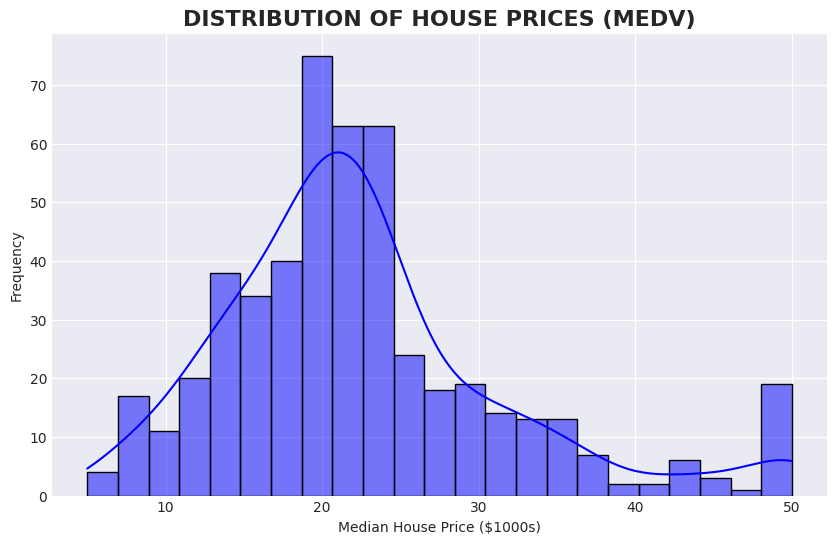


INSIGHT: House prices are right-skewed with some high-value outliers.

Target variable loaded successfully!


In [ ]:
# ============================
# 3. Exploratory Data Analysis
# ============================
print("=== SUMMARY STATISTICS ===")
display(df.describe().round(3))

# Target Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['medv'], kde=True, color='blue')
plt.title('DISTRIBUTION OF HOUSE PRICES (MEDV)', fontsize=16, fontweight='bold')
plt.xlabel('Median House Price ($1000s)')
plt.ylabel('Frequency')
os.makedirs('../../visualizations', exist_ok=True)
plt.savefig('../../visualizations/regression_medv_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("INSIGHT: House prices are right-skewed with some high-value outliers.")
print("="*60)
print("\nTarget variable loaded successfully!")

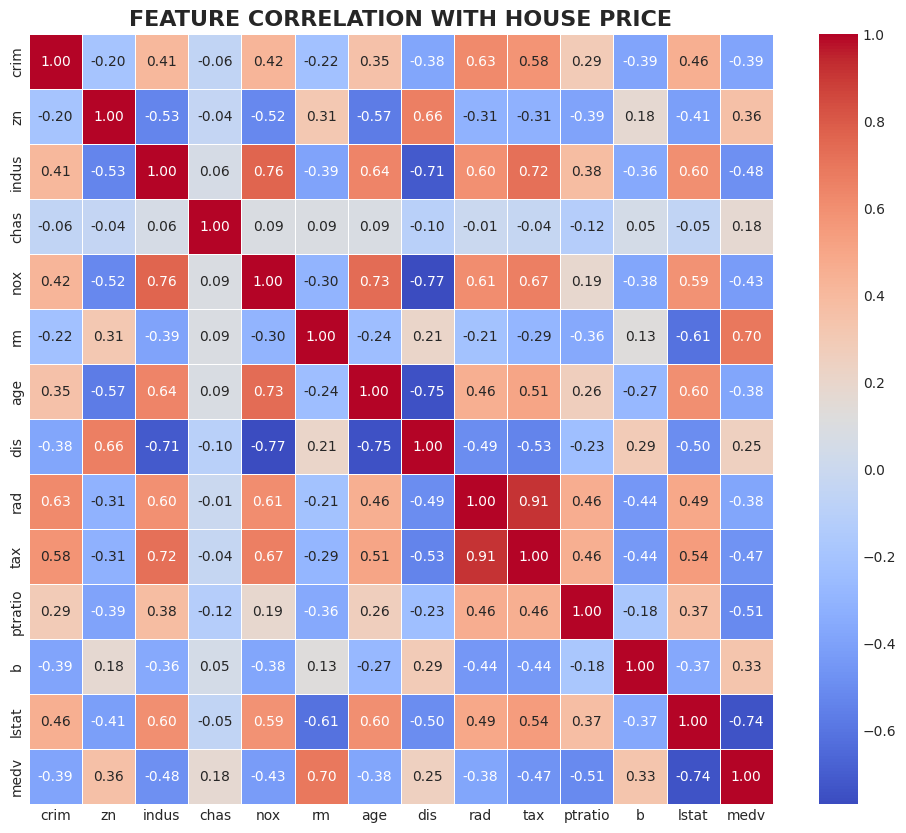


Top Features Correlated with MEDV:
medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64

KEY INSIGHTS FROM CORRELATION ANALYSIS
RM (number of rooms) has the strongest positive correlation,
while LSTAT (lower status population) has the strongest negative correlation with house prices.


In [ ]:
# ============================
# 4. Correlation Analysis
# ============================
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('FEATURE CORRELATION WITH HOUSE PRICE', fontsize=16, fontweight='bold')
plt.savefig('../../visualizations/regression_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop Features Correlated with MEDV:")
print(corr['medv'].sort_values(ascending=False))

# After the correlation heatmap
print("\n" + "="*60)
print("KEY INSIGHTS FROM CORRELATION ANALYSIS")
print("="*60)
print("RM (number of rooms) has the strongest positive correlation,")
print("while LSTAT (lower status population) has the strongest negative correlation with house prices.")

In [ ]:
# ============================
# 5. Feature Selection & Train-Test Split
# ============================
features = ['rm', 'lstat', 'dis', 'crim', 'tax', 'age', 'ptratio']
X = df[features]
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 404
Testing samples: 102


In [ ]:
# ============================
# 6. Model Training
# ============================
model = LinearRegression()

model.fit(X_train, y_train)

# Statsmodels Summary (Scrollable)
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()

# Display full summary in scrollable box
html = model_sm.summary().as_html()
display(HTML(f'<div style="max-height: 700px; overflow: auto;">{html}</div>'))

In [ ]:
# ============================
# 6b. Model Interpretation
# ============================
print("\n" + "="*80)
print("OLS REGRESSION RESULTS - DETAILED INTERPRETATION")
print("="*80)

print(f"""
R-squared: {model_sm.rsquared:.4f} → Model explains **{model_sm.rsquared*100:.1f}%** of house price variation.

Key Significant Features:
• RM (+{model_sm.params['rm']:.4f}): Every extra room increases price by ~${model_sm.params['rm']*1000:.0f}
• LSTAT ({model_sm.params['lstat']:.4f}): Strong negative impact
• DIS, CRIM, PTRATIO: All statistically significant negative effects
""")


OLS REGRESSION RESULTS - DETAILED INTERPRETATION

R-squared: 0.7135 → Model explains **71.3%** of house price variation.

Key Significant Features:
• RM (+4.8970): Every extra room increases price by ~$4897
• LSTAT (-0.5723): Strong negative impact
• DIS, CRIM, PTRATIO: All statistically significant negative effects



=== MODEL PERFORMANCE ===
MAE  : $3.38K
RMSE : $5.28K
R²   : 0.6205 (62.0%)


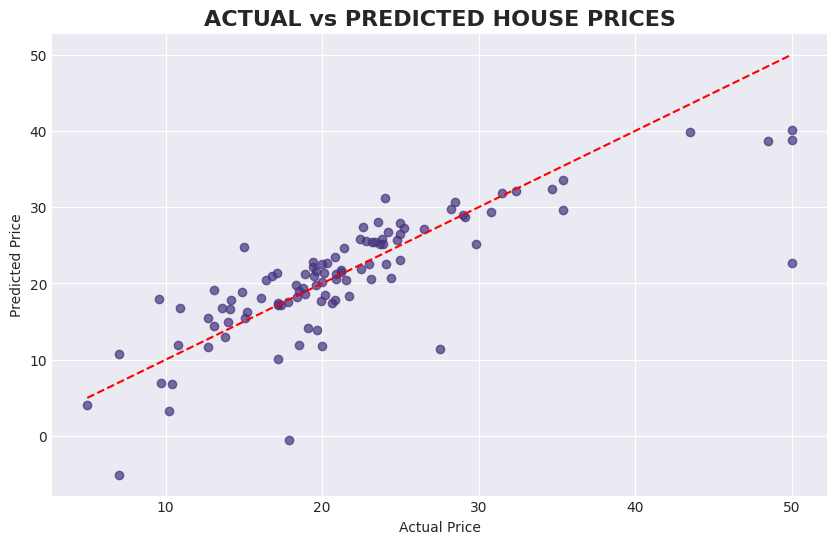

In [ ]:
# ============================
# 7. Model Evaluation
# ============================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MODEL PERFORMANCE ===")
print(f"MAE  : ${mae:.2f}K")
print(f"RMSE : ${rmse:.2f}K")
print(f"R²   : {r2:.4f} ({r2*100:.1f}%)")

# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('ACTUAL vs PREDICTED HOUSE PRICES', fontsize=16, fontweight='bold')
plt.savefig('../../visualizations/regression_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

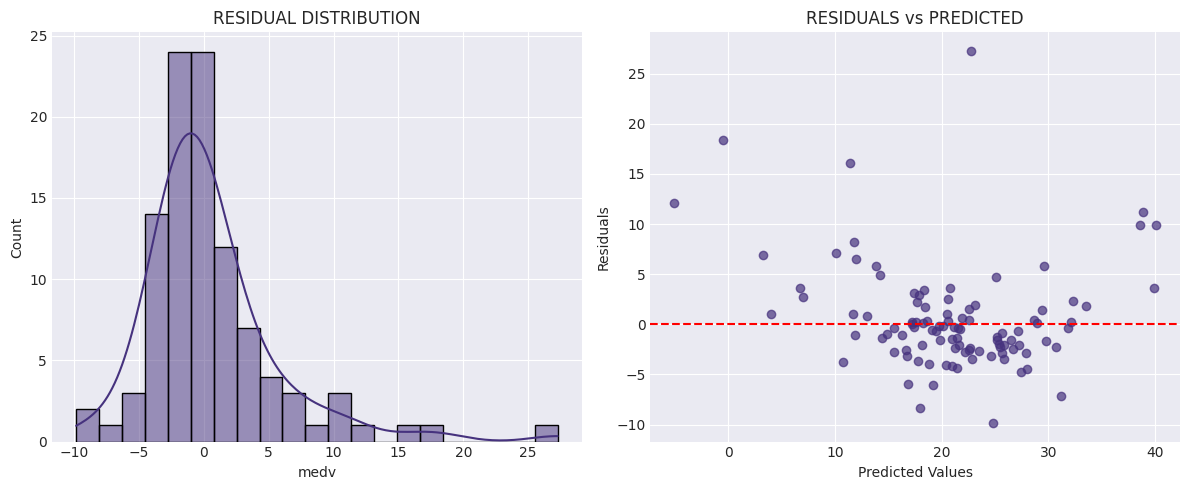

In [ ]:
# ============================
# 8. Residual Analysis
# ============================
residuals = y_test - y_pred

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('RESIDUAL DISTRIBUTION')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('RESIDUALS vs PREDICTED')

plt.tight_layout()
plt.savefig('../../visualizations/regression_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

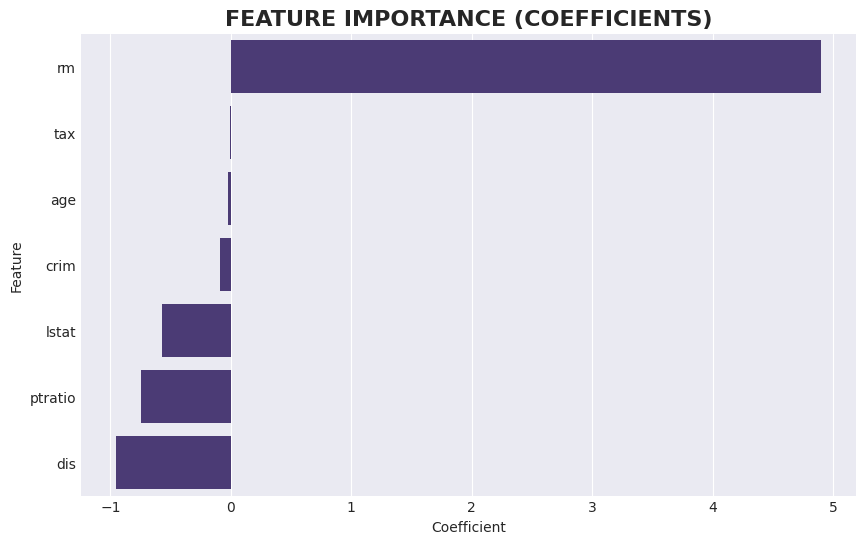

   Feature  Coefficient
0       rm       4.8970
4      tax      -0.0042
5      age      -0.0232
3     crim      -0.0905
1    lstat      -0.5723
6  ptratio      -0.7480
2      dis      -0.9506


In [ ]:
# ============================
# 9. Feature Importance
# ============================
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature')
plt.title('FEATURE IMPORTANCE (COEFFICIENTS)', fontsize=16, fontweight='bold')
plt.savefig('../../visualizations/regression_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(coefficients.round(4))

In [ ]:
# ============================
# 10. Final Insights & Conclusions
# ============================
print("\n" + "="*70)
print("REGRESSION ANALYSIS - KEY INSIGHTS")
print("="*70)
print("""
1. The model explains {:.1f}% of the variance in house prices (R² = {:.4f}).

2. Most influential positive factor: Number of Rooms (RM) → More rooms = Higher price.

3. Strongest negative factor: LSTAT (% lower status population) → Higher LSTAT = Lower price.

4. Crime rate (CRIM) and distance to employment centers (DIS) also significantly affect prices.

5. Model performs reasonably well but shows some heteroscedasticity in residuals.

Recommendations:
- Address multicollinearity (consider removing correlated features like TAX/RAD).
- Try polynomial features or ensemble models (Random Forest, XGBoost) for better performance.
- Focus on homes with more rooms in low-crime, well-educated neighborhoods.
""".format(r2*100, r2))
print("="*70)


REGRESSION ANALYSIS - KEY INSIGHTS

1. The model explains 62.0% of the variance in house prices (R² = 0.6205).

2. Most influential positive factor: Number of Rooms (RM) → More rooms = Higher price.

3. Strongest negative factor: LSTAT (% lower status population) → Higher LSTAT = Lower price.

4. Crime rate (CRIM) and distance to employment centers (DIS) also significantly affect prices.

5. Model performs reasonably well but shows some heteroscedasticity in residuals.

Recommendations:
- Address multicollinearity (consider removing correlated features like TAX/RAD).
- Try polynomial features or ensemble models (Random Forest, XGBoost) for better performance.
- Focus on homes with more rooms in low-crime, well-educated neighborhoods.

